<a href="https://colab.research.google.com/github/Dzikri240105/UAS-KecerdasanBuatan/blob/main/uas_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                              accuracy_score, precision_score,
                              recall_score, f1_score, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)



In [87]:
df = pd.read_csv('/content/drive/MyDrive/UAS_Kecerdasan Buatan/healthcare-dataset-stroke-data.csv')
print('Ukuran data:', df.shape)
df.head()


Ukuran data: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [88]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [89]:
# Informasi umum dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [90]:
# Statistik deskriptif data numerik
df.describe()


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [91]:
# Cek jumlah nilai unik tiap kolom kategorik
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")


gender: ['Male' 'Female' 'Other']
ever_married: ['Yes' 'No']
work_type: ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type: ['Urban' 'Rural']
smoking_status: ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


## 3. Exploratory Data Analysis (EDA)

Pada tahap ini dilakukan eksplorasi data untuk memahami distribusi, hubungan antar fitur, serta mendeteksi ketidakseimbangan kelas (imbalanced classes) sebelum dilakukan pemodelan.


/tmp/ipykernel_8823/625282568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='stroke', data=df, palette='Set2')


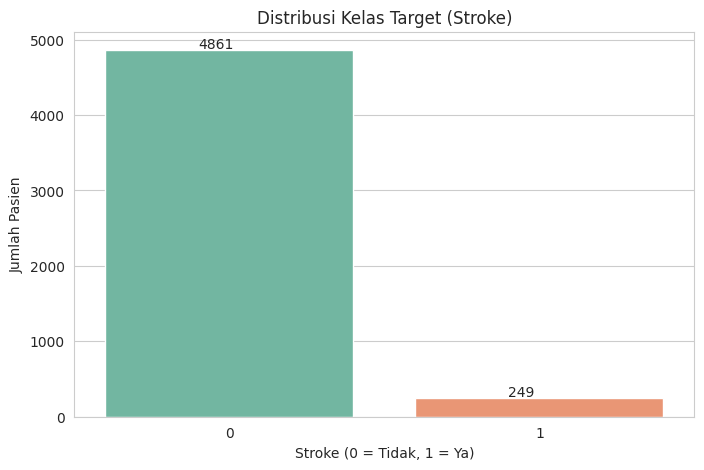

stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64


In [92]:
# Distribusi kelas target (stroke)
plt.figure()
ax = sns.countplot(x='stroke', data=df, palette='Set2')
plt.title('Distribusi Kelas Target (Stroke)')
plt.xlabel('Stroke (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Pasien')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.3, p.get_height()+20))
plt.show()

print(df['stroke'].value_counts(normalize=True) * 100)


**Insight:** Dari grafik di atas terlihat distribusi kelas target sangat tidak seimbang (*imbalanced*), dengan jumlah pasien tanpa stroke jauh lebih banyak dibandingkan pasien dengan stroke. Hal ini perlu ditangani pada tahap *Data Preparation* (misalnya dengan teknik SMOTE) agar model tidak bias terhadap kelas mayoritas.

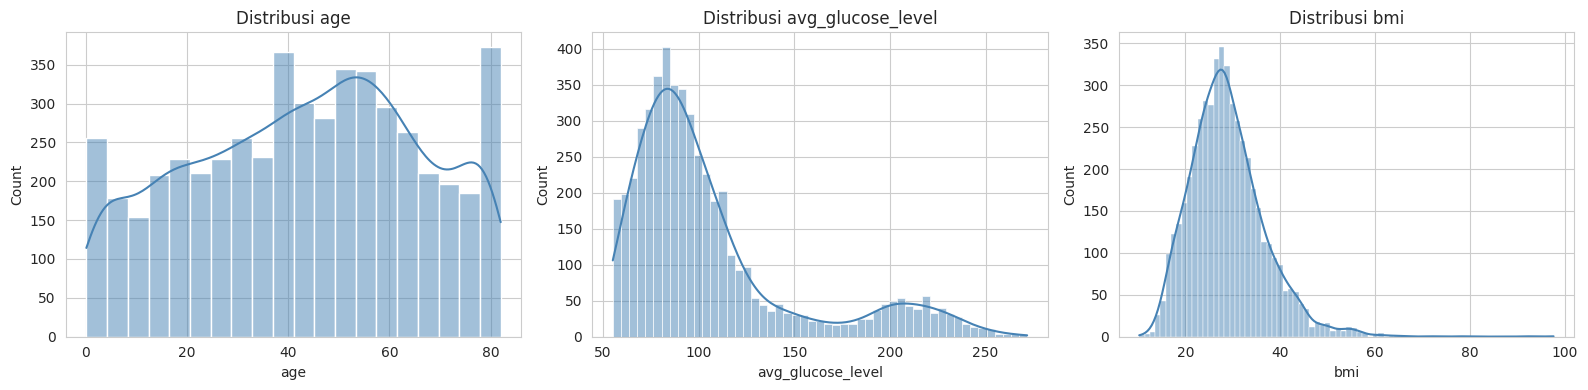

In [93]:
# Distribusi fitur numerik (histogram)
num_cols = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribusi {col}')
plt.tight_layout()
plt.show()


/tmp/ipykernel_8823/1660755174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, ax=axes[i], palette='Set3',
/tmp/ipykernel_8823/1660755174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, ax=axes[i], palette='Set3',
/tmp/ipykernel_8823/1660755174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=col, data=df, ax=axes[i], palette='Set3',
/tmp/ipykernel_8823/1660755174.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` var

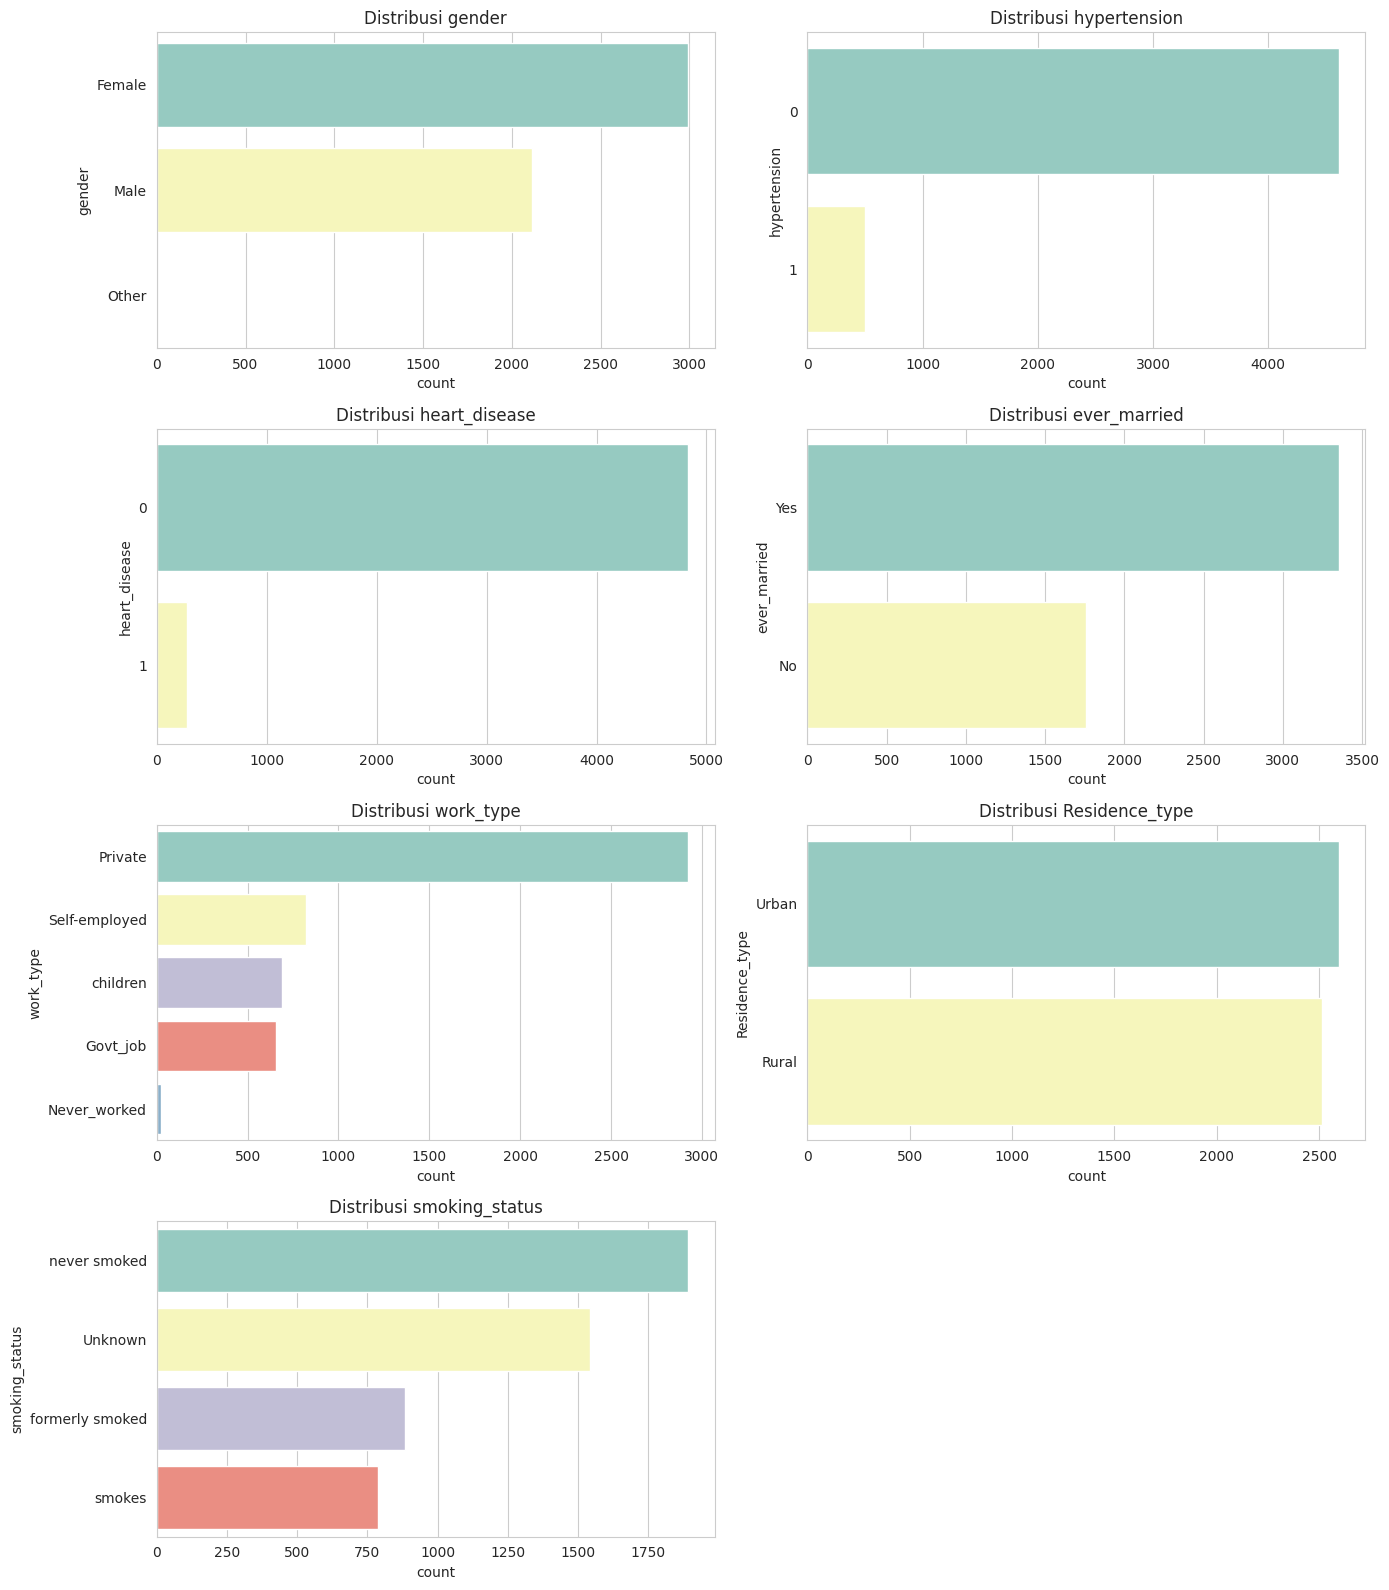

In [94]:
# Distribusi fitur kategorik (bar chart)
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married',
            'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(y=col, data=df, ax=axes[i], palette='Set3',
                  order=df[col].value_counts().index)
    axes[i].set_title(f'Distribusi {col}')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


/tmp/ipykernel_8823/472178272.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_8823/472178272.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_8823/472178272.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='stroke', y=col, data=df, ax=axes[i], palette='Set2')


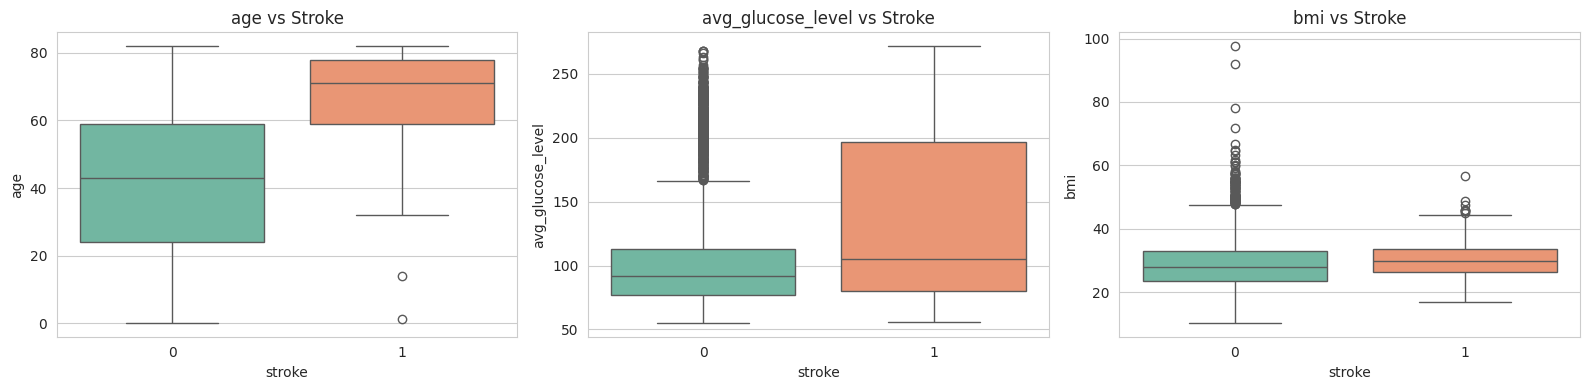

In [95]:
# Perbandingan fitur numerik terhadap target stroke
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(x='stroke', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{col} vs Stroke')
plt.tight_layout()
plt.show()


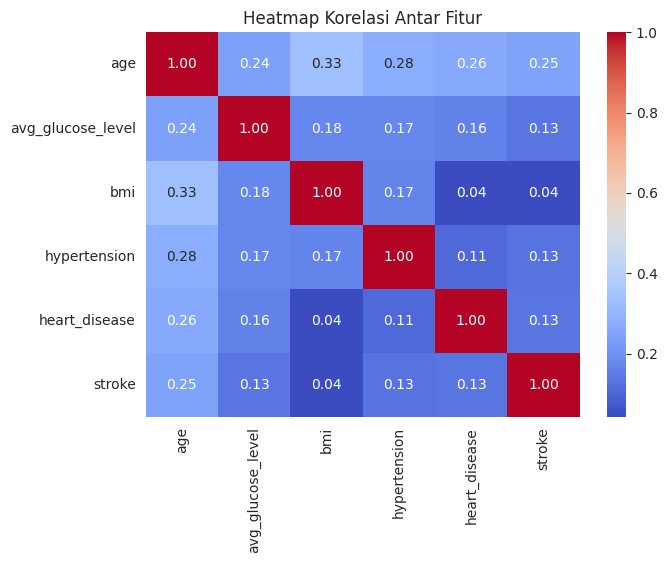

In [96]:
# Heatmap korelasi antar fitur numerik
plt.figure(figsize=(7, 5))
corr = df[['age', 'avg_glucose_level', 'bmi', 'hypertension',
           'heart_disease', 'stroke']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()


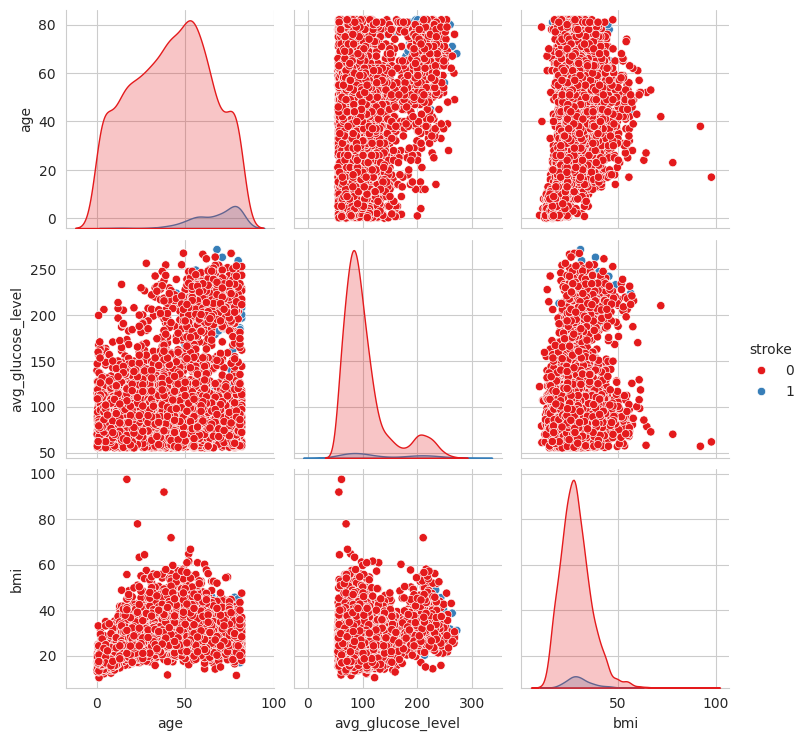

In [97]:
# Pairplot untuk melihat hubungan antar fitur numerik berdasarkan target
sns.pairplot(df[['age', 'avg_glucose_level', 'bmi', 'stroke']].dropna(),
             hue='stroke', palette='Set1', diag_kind='kde')
plt.show()


**Insight Awal dari Pola Data:**
- Pasien yang mengalami stroke cenderung memiliki usia (`age`) yang lebih tua dibandingkan pasien yang tidak stroke.
- Rata-rata kadar glukosa (`avg_glucose_level`) pada pasien stroke cenderung lebih tinggi.
- Fitur `age` memiliki korelasi positif paling kuat terhadap `stroke` dibandingkan fitur numerik lainnya.
- Distribusi kelas target sangat tidak seimbang, sehingga diperlukan penanganan *imbalanced data* sebelum pemodelan.
- Terdapat nilai kosong (missing value) pada kolom `bmi` yang perlu dibersihkan pada tahap *Data Preparation*.


## 4. Data Preparation

Tahap ini bertujuan untuk membersihkan dan mentransformasi data mentah menjadi data siap latih (*train-ready*), meliputi penanganan missing value, duplikasi, encoding data kategorik, normalisasi data numerik, penanganan data tidak seimbang, dan pembagian data latih-uji.


In [98]:
# Cek missing value
print('Jumlah missing value per kolom:')
print(df.isnull().sum())


Jumlah missing value per kolom:
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [99]:
# Cek duplikasi data
print('Jumlah baris duplikat:', df.duplicated().sum())


Jumlah baris duplikat: 0


In [100]:
# Membersihkan data
df_clean = df.copy()

# Hapus kolom id karena tidak relevan untuk pemodelan
df_clean.drop('id', axis=1, inplace=True)

# Hapus kategori 'Other' pada gender karena jumlahnya sangat sedikit (outlier kategorik)
df_clean = df_clean[df_clean['gender'] != 'Other'].copy()

# Tangani missing value pada kolom bmi dengan median (karena distribusinya skewed)
df_clean['bmi'] = df_clean['bmi'].fillna(df_clean['bmi'].median())

# Hapus duplikasi (jika ada)
df_clean.drop_duplicates(inplace=True)

print('Ukuran data setelah dibersihkan:', df_clean.shape)
df_clean.isnull().sum()


Ukuran data setelah dibersihkan: (5109, 11)


,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0
smoking_status,0


In [101]:
# Encoding data kategorik
# Label Encoding untuk fitur biner/ordinal
label_cols = ['gender', 'ever_married', 'Residence_type']
le = LabelEncoder()
for col in label_cols:
    df_clean[col] = le.fit_transform(df_clean[col])

# One-Hot Encoding untuk fitur nominal dengan >2 kategori
df_clean = pd.get_dummies(df_clean, columns=['work_type', 'smoking_status'], drop_first=True)

df_clean.head()


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,67.0,0,1,1,1,228.69,36.6,1,False,True,False,False,True,False,False
1,0,61.0,0,0,1,0,202.21,28.1,1,False,False,True,False,False,True,False
2,1,80.0,0,1,1,0,105.92,32.5,1,False,True,False,False,False,True,False
3,0,49.0,0,0,1,1,171.23,34.4,1,False,True,False,False,False,False,True
4,0,79.0,1,0,1,0,174.12,24.0,1,False,False,True,False,False,True,False


In [102]:
# Pisahkan fitur (X) dan target (y)
X = df_clean.drop('stroke', axis=1)
y = df_clean['stroke']

# Normalisasi/Standardisasi data numerik
num_features = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
X[num_features] = scaler.fit_transform(X[num_features])

X.head()


,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,1.051242,0,1,1,1,2.706450,1.004893,False,True,False,False,True,False,False
1,0,0.785889,0,0,1,0,2.121652,-0.099142,False,False,True,False,False,True,False
2,1,1.626174,0,1,1,0,-0.004867,0.472358,False,True,False,False,False,True,False
3,0,0.255182,0,0,1,1,1.437473,0.719142,False,True,False,False,False,False,True
4,0,1.581949,1,0,1,0,1.501297,-0.631677,False,False,True,False,False,True,False


In [103]:
# Split data train-test (80:20) dengan stratifikasi karena data tidak seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Distribusi y_train sebelum SMOTE:')
print(y_train.value_counts())

# Tangani imbalanced data dengan SMOTE (hanya pada data latih)
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('\nDistribusi y_train setelah SMOTE:')
print(y_train_res.value_counts())

print('\nUkuran data latih:', X_train_res.shape)
print('Ukuran data uji  :', X_test.shape)


Distribusi y_train sebelum SMOTE:
stroke
0    3888
1     199
Name: count, dtype: int64

Distribusi y_train setelah SMOTE:
stroke
0    3888
1    3888
Name: count, dtype: int64

Ukuran data latih: (7776, 15)
Ukuran data uji  : (1022, 15)


## 5. Modeling

**Pemilihan Algoritma**
Pada proyek ini digunakan tiga algoritma klasifikasi untuk dibandingkan performanya:
1. **Decision Tree** - mudah diinterpretasi dan dapat memvisualisasikan aturan keputusan.
2. **K-Nearest Neighbors (KNN)** - algoritma berbasis kedekatan jarak antar data, sederhana namun cukup efektif untuk data klinis.
3. **Random Forest** - ensemble dari banyak decision tree yang umumnya lebih stabil dan tahan terhadap overfitting dibandingkan single decision tree.

**Alasan Pemilihan Model**
Decision Tree dipilih karena interpretasinya yang mudah dipahami oleh tenaga medis non-teknis. KNN dipilih sebagai pembanding berbasis instance-based learning. Random Forest dipilih untuk meningkatkan akurasi dan mengurangi risiko overfitting yang umum terjadi pada single Decision Tree, sekaligus memberikan informasi *feature importance*.


In [104]:
# 1. Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train_res, y_train_res)
y_pred_dt = dt_model.predict(X_test)


In [105]:
# 2. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_res, y_train_res)
y_pred_knn = knn_model.predict(X_test)


In [106]:
# 3. Random Forest
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train_res, y_train_res)
y_pred_rf = rf_model.predict(X_test)


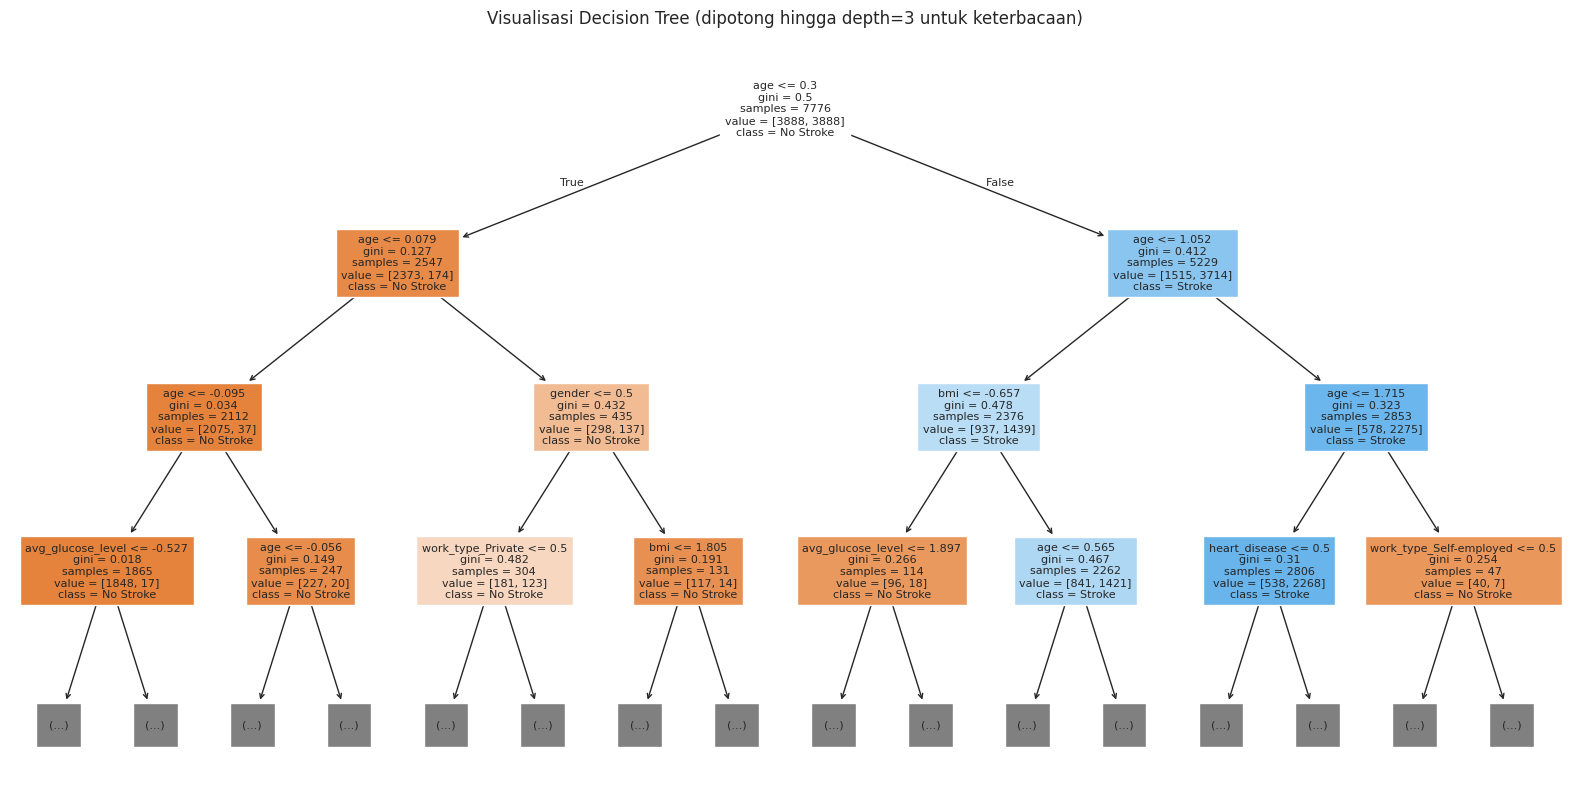

In [107]:
# Visualisasi pohon keputusan (Decision Tree)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X.columns, class_names=['No Stroke', 'Stroke'],
          filled=True, max_depth=3, fontsize=8)
plt.title('Visualisasi Decision Tree (dipotong hingga depth=3 untuk keterbacaan)')
plt.show()


/tmp/ipykernel_8823/2075136932.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis')


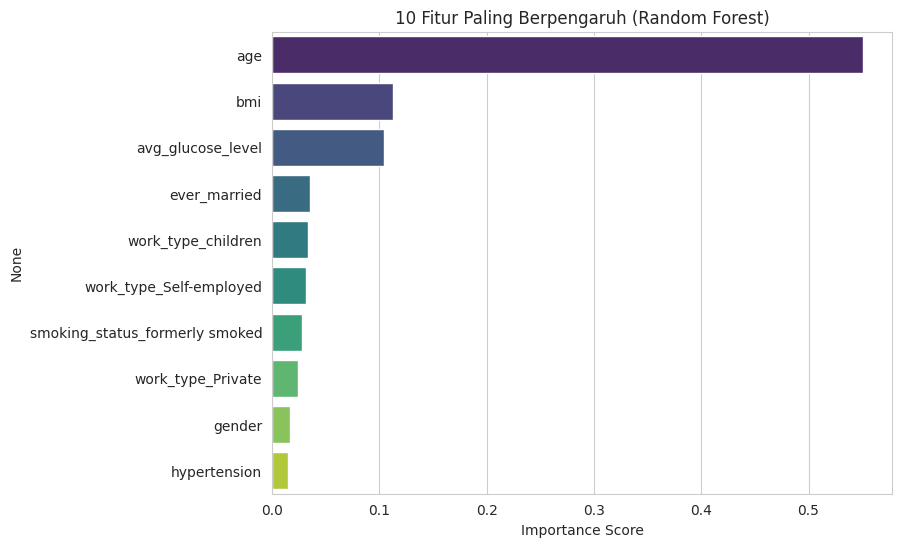

In [108]:
# Visualisasi feature importance dari Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], palette='viridis')
plt.title('10 Fitur Paling Berpengaruh (Random Forest)')
plt.xlabel('Importance Score')
plt.show()


## 6. Evaluation

Evaluasi dilakukan menggunakan *confusion matrix* serta metrik *accuracy, precision, recall,* dan *F1-score* untuk membandingkan performa ketiga model pada data uji.


In [109]:
def evaluate_model(name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"=== {name} ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(classification_report(y_test, y_pred, target_names=['No Stroke', 'Stroke']))
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results = []
results.append(evaluate_model('Decision Tree', y_test, y_pred_dt))
results.append(evaluate_model('K-Nearest Neighbors', y_test, y_pred_knn))
results.append(evaluate_model('Random Forest', y_test, y_pred_rf))


=== Decision Tree ===
Accuracy  : 0.7387
Precision : 0.1193
Recall    : 0.6800
F1-Score  : 0.2030
              precision    recall  f1-score   support

   No Stroke       0.98      0.74      0.84       972
      Stroke       0.12      0.68      0.20        50

    accuracy                           0.74      1022
   macro avg       0.55      0.71      0.52      1022
weighted avg       0.94      0.74      0.81      1022

=== K-Nearest Neighbors ===
Accuracy  : 0.7838
Precision : 0.1023
Recall    : 0.4400
F1-Score  : 0.1660
              precision    recall  f1-score   support

   No Stroke       0.97      0.80      0.88       972
      Stroke       0.10      0.44      0.17        50

    accuracy                           0.78      1022
   macro avg       0.53      0.62      0.52      1022
weighted avg       0.92      0.78      0.84      1022

=== Random Forest ===
Accuracy  : 0.7466
Precision : 0.1227
Recall    : 0.6800
F1-Score  : 0.2080
              precision    recall  f1-score   

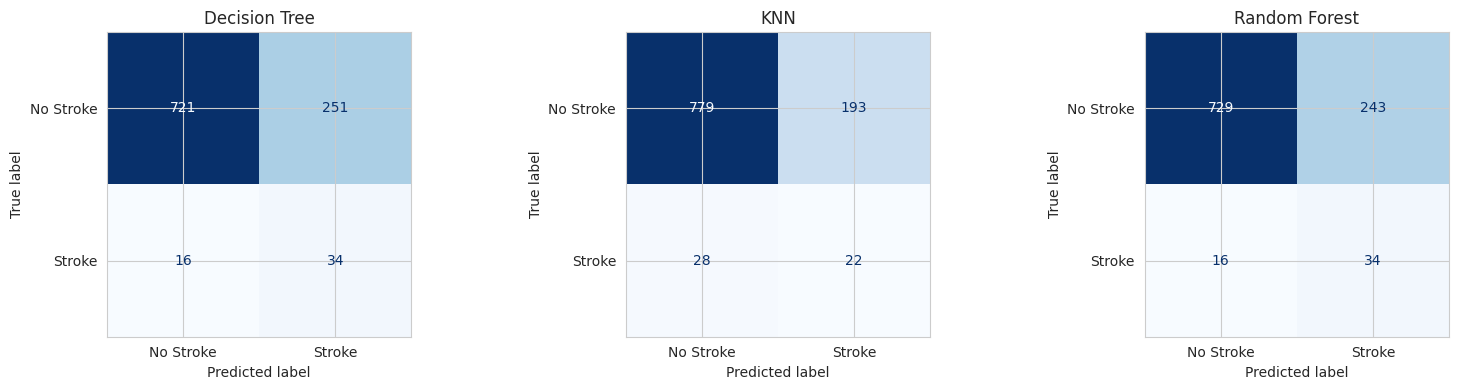

In [110]:
# Visualisasi confusion matrix untuk ketiga model
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
preds = {'Decision Tree': y_pred_dt, 'KNN': y_pred_knn, 'Random Forest': y_pred_rf}
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()


In [111]:
# Tabel perbandingan performa model
results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.746575,0.122744,0.68,0.207951
1,Decision Tree,0.738748,0.119298,0.68,0.202985
2,K-Nearest Neighbors,0.783757,0.102326,0.44,0.166038


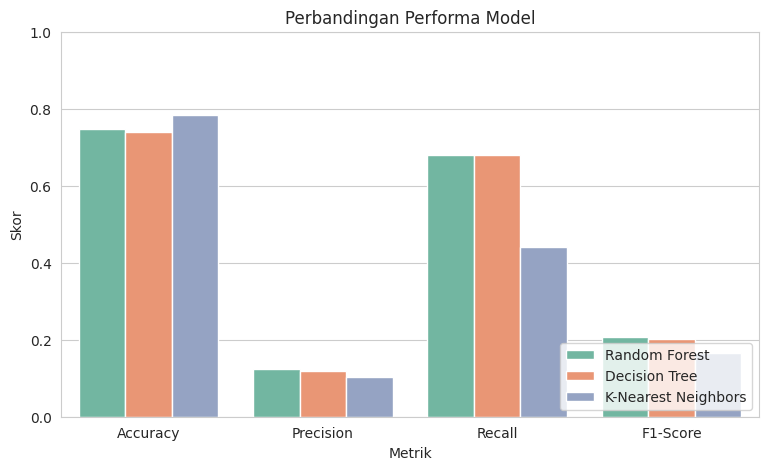

In [112]:
# Visualisasi perbandingan metrik antar model
results_melt = results_df.melt(id_vars='Model', var_name='Metrik', value_name='Skor')
plt.figure(figsize=(9, 5))
sns.barplot(x='Metrik', y='Skor', hue='Model', data=results_melt, palette='Set2')
plt.title('Perbandingan Performa Model')
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()
